# DAG examples — from scratch vs. from manifest

Worked examples for `jobs.py`/`dag.py`, following the training pipeline in
`job-spec.md`'s appendix: `DownloadSource` → `TrainTokenizer` → `TokenizeSource`
→ `BuildSplit` → `Pretrain` → `SFT`.

Two ways to build the same DAG:

- **from scratch** — construct every job bottom-up, passing each finished job
  straight into the next one's dependency slots.
- **from a manifest** — point a slot at an already-saved manifest path instead.
  `Job.from_manifest` defaults to a *deep* load: every nested dependency in the
  manifest's recursive recipe is itself reconstructed as a live job, so
  parameters are re-validated and every level's id is re-derived and checked
  against what was recorded — all the way up the ancestry, not just the one
  job named by the path. Pass `frozen=True` for the cheaper alternative: stop
  there, treat it as a leaf, don't rebuild (or re-check) anything upstream.

Both land on the identical job `id` for anything built the same way, so a
notebook session can pick a pipeline up from wherever it left off instead of
restating it.

In [21]:
import json
import shutil
from pathlib import Path

from jobs import (
    DownloadSource, TrainTokenizer, TokenizeSource, BuildSplit, Pretrain, SFT,
    Job, JobError,
)
import dag

ROOT = Path("example_data")
shutil.rmtree(ROOT, ignore_errors=True)   # re-runnable from a clean slate
ROOT.mkdir()

RUN_ID = "gpt2-small-v1"

Every job type also overrides `__init__` with an explicit, fully typed
signature -- `parameters` typed as that type's own `Parameters` model, a
named keyword per dependency slot -- that does nothing but call
`Job.__init__`. Construction behavior lives in one place; the overrides
exist purely so an editor shows each type's real shape (dependency slot
names, and -- via `Parameters`, which Pylance/Pyright already understand
natively -- parameter fields when you construct one explicitly) instead of
`Job`'s generic `parameters: dict, **deps: list`. A plain `{...}` dict for
`parameters` still works at runtime either way (`model_validate` accepts
both), matching every example in job-spec.md's appendix; it just doesn't
get field-by-field autocomplete the way `TrainTokenizer.Parameters(...)`
does, since a bare dict isn't shape-typed. Hover or autocomplete on
`TrainTokenizer(` in an editor to see it; `inspect.signature` shows the
same thing here.

In [22]:
import inspect

print(inspect.signature(TrainTokenizer.__init__))
print(TrainTokenizer.__init__.__annotations__["parameters"])

# same fields, now via the model Pylance/Pyright already autocomplete for you
tp = TrainTokenizer.Parameters(
    tokenizer_uid="llama-64", vocab_size=64, kind="bpe", token_source_uids=["odyssey"],
)
print(tp)

(self, parameters: jobs.TrainTokenizer.Parameters | dict, run_id: str, root: str | pathlib.Path = '.', *, sources: list[jobs.DownloadSource | str | pathlib.Path] = ()) -> None
jobs.TrainTokenizer.Parameters | dict
tokenizer_uid='llama-64' vocab_size=64 kind='bpe' special_tokens=[] token_source_uids=['odyssey']


## 1. Build the DAG from scratch

`Job(parameters: dict, run_id: str, root=ROOT, **dependencies)` — every
dependency kwarg is a **list**, always, even a single one. This mirrors
job-spec.md's own appendix example almost verbatim.

In [23]:
VOCAB_SIZE = 64
TRAIN_SET = ["odyssey", "mobydick"]
VALID_SET = ["montecristo", "romeojuliet"]
TOKEN_SET = ["odyssey", "mobydick"]


def src(name):
    return DownloadSource(
        {"source_uid": name, "url": f"https://example.org/{name}.txt",
         "type": "text", "config": {"normalizer": "lowercase"}},
        RUN_ID, root=ROOT,
    )


sources = {name: src(name) for name in set(TRAIN_SET + VALID_SET)}

tokenizer = TrainTokenizer(
    {"tokenizer_uid": "llama-64", "vocab_size": VOCAB_SIZE, "kind": "bpe",
     "special_tokens": ["<|endoftext|>", "<|begin|>", "<|end|>"],
     "token_source_uids": TOKEN_SET},
    RUN_ID, root=ROOT,
    sources=[sources[name] for name in TOKEN_SET],
)

tokenized = {
    name: TokenizeSource(
        {"tokenizer_uid": "llama-64", "source_uid": name},
        RUN_ID, root=ROOT,
        source=[sources[name]], tokenizer=[tokenizer],
    )
    for name in set(TRAIN_SET + VALID_SET)
}

dataset = BuildSplit(
    {"train_source_uids": TRAIN_SET, "valid_source_uids": VALID_SET,
     "tokenizer_uid": "llama-64"},
    RUN_ID, root=ROOT,
    tokenizer=[tokenizer],
    sources=[tokenized[name] for name in set(TRAIN_SET + VALID_SET)],
)

pretrain = Pretrain(
    {"run_id": RUN_ID, "model_config": {"n_layer": 2, "n_embd": 64},
     "training_config": {"lr": 3e-4, "epochs": 1}},
    RUN_ID, root=ROOT,
    dataset=[dataset],
)

sft = SFT(
    {"run_id": RUN_ID, "base_run_id": RUN_ID,
     "sft_training_config": {"lr": 1e-5, "epochs": 2}},
    RUN_ID, root=ROOT,
    base=[pretrain],
)

print("target id:", sft.id)

target id: df223936588e


## 2. Topological order + status, before anything is materialized

`dag.status()` reads only what's on disk: `done` once every output exists,
`runnable` once every input exists (and it isn't done), else `blocked`. The two
`DownloadSource` jobs have no inputs, so they're immediately `runnable`;
everything downstream is `blocked` until its own inputs show up.

In [24]:
order = dag.topo_sort(sft)


def print_status(order):
    for j in order:
        print(f"{type(j).__name__:16s} {j.id}  {dag.status(j)}")


print_status(order)

DownloadSource   b01d134b4b9b  runnable
DownloadSource   dbcb09b964c9  runnable
TrainTokenizer   00bcd290b0ef  blocked
DownloadSource   e5bf72092b66  runnable
TokenizeSource   b4aef00e1f9a  blocked
TokenizeSource   71f5178174fe  blocked
DownloadSource   2f47feabd981  runnable
TokenizeSource   06a09a806858  blocked
TokenizeSource   991377c1230b  blocked
BuildSplit       88a6570a5cf6  blocked
Pretrain         59a9a9875c1b  blocked
SFT              df223936588e  blocked


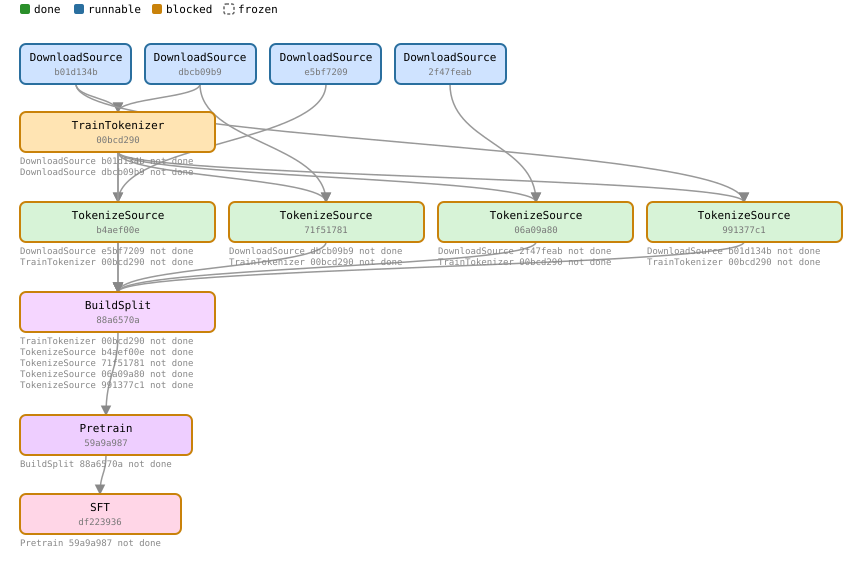

In [25]:
dag.dag_svg(sft)   # last line of the cell -- Jupyter renders the SVG directly

## 3. Materialize — walk status from blocked to done

job-spec.md deliberately stops at structure: it declares output *paths*, not
how to produce them. So here we just drop placeholder files at each job's
declared output paths ourselves, stage by stage, and watch `dag.status()`
react — no toy training loop needed to see the DAG behave correctly.

In [26]:
def materialize(job, output_name, filename="data.bin", content=b"placeholder"):
    """Write a placeholder file at job's declared output path for
    output_name -- into the glob directory for a "*" template, or the exact
    path otherwise."""
    fields = {**job.parameters.model_dump(mode="json"), "run_id": job.run_id, "id": job.id}
    pattern = job.outputs[output_name].format(**fields)
    path = (job.root / pattern[:-1] / filename) if pattern.endswith("*") else (job.root / pattern)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(content) if isinstance(content, bytes) else path.write_text(content)
    return path


for name, job in sources.items():
    materialize(job, "text", filename="part1.txt", content=f"text of {name}")
print("after materializing sources:")
print_status(order)

after materializing sources:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  runnable
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  blocked
TokenizeSource   71f5178174fe  blocked
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  blocked
TokenizeSource   991377c1230b  blocked
BuildSplit       88a6570a5cf6  blocked
Pretrain         59a9a9875c1b  blocked
SFT              df223936588e  blocked


In [27]:
materialize(tokenizer, "tokenizer", filename="tokenizer.json", content="{}")
materialize(tokenizer, "config", filename="config.json", content="{}")
print("after materializing the tokenizer:")
print_status(order)

after materializing the tokenizer:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  runnable
TokenizeSource   71f5178174fe  runnable
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  runnable
TokenizeSource   991377c1230b  runnable
BuildSplit       88a6570a5cf6  blocked
Pretrain         59a9a9875c1b  blocked
SFT              df223936588e  blocked


In [28]:
for job in tokenized.values():
    materialize(job, "bin", filename="shard0.bin")
print("after materializing tokenized sources:")
print_status(order)

after materializing tokenized sources:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  done
TokenizeSource   71f5178174fe  done
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  done
TokenizeSource   991377c1230b  done
BuildSplit       88a6570a5cf6  runnable
Pretrain         59a9a9875c1b  blocked
SFT              df223936588e  blocked


In [29]:
materialize(dataset, "train", content=b"train")
materialize(dataset, "valid", content=b"valid")
print("after materializing the dataset split:")
print_status(order)

after materializing the dataset split:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  done
TokenizeSource   71f5178174fe  done
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  done
TokenizeSource   991377c1230b  done
BuildSplit       88a6570a5cf6  done
Pretrain         59a9a9875c1b  runnable
SFT              df223936588e  blocked


In [30]:
materialize(pretrain, "checkpoints", filename="step1000.pt")
materialize(pretrain, "logs", filename="train.log", content="loss=...")
materialize(pretrain, "progress", content="{}")
materialize(sft, "checkpoints", filename="step500.pt")
materialize(sft, "logs", filename="train.log", content="loss=...")
materialize(sft, "progress", content="{}")
print("after materializing pretrain + sft:")
print_status(order)

after materializing pretrain + sft:
DownloadSource   b01d134b4b9b  done
DownloadSource   dbcb09b964c9  done
TrainTokenizer   00bcd290b0ef  done
DownloadSource   e5bf72092b66  done
TokenizeSource   b4aef00e1f9a  done
TokenizeSource   71f5178174fe  done
DownloadSource   2f47feabd981  done
TokenizeSource   06a09a806858  done
TokenizeSource   991377c1230b  done
BuildSplit       88a6570a5cf6  done
Pretrain         59a9a9875c1b  done
SFT              df223936588e  done


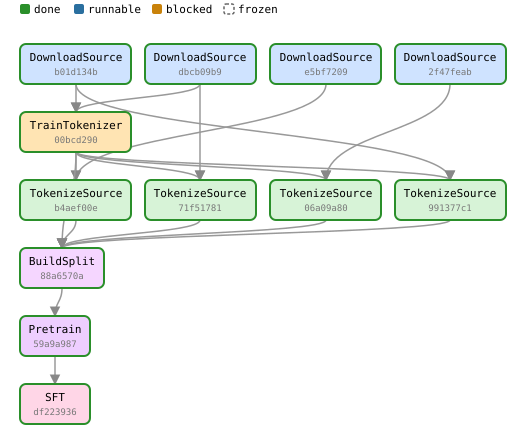

In [31]:
dag.dag_svg(sft)   # same DAG, now every box green

## 4. Save manifests

`job.save(path)` writes `job.to_manifest()` — the §5 schema, a **recursive
recipe** (each dependency nested inline as its own manifest), not a flat
graph. `job.to_manifest()` on its own just returns the dict without writing.

In [32]:
odyssey_manifest = sources["odyssey"].save(f"sources/odyssey/manifest.json")
tokenizer_manifest = tokenizer.save(f"tokenizers/llama-64/manifest.json")
for name, job in tokenized.items():
    job.save(f"tokenizers/llama-64/bin/{name}/manifest.json")
dataset_manifest = dataset.save(f"datasets/{dataset.id}/manifest.json")
pretrain_manifest = pretrain.save(f"runs/{RUN_ID}/pretrain/manifest.json")

print("saved:", tokenizer_manifest)
print(json.dumps(tokenizer.to_manifest(), indent=2)[:600], "...")

saved: tokenizers/llama-64/manifest.json
{
  "id": "00bcd290b0ef",
  "job_type": "TrainTokenizer",
  "run_id": "gpt2-small-v1",
  "parameters": {
    "tokenizer_uid": "llama-64",
    "vocab_size": 64,
    "kind": "bpe",
    "special_tokens": [
      "<|endoftext|>",
      "<|begin|>",
      "<|end|>"
    ],
    "token_source_uids": [
      "odyssey",
      "mobydick"
    ]
  },
  "dependencies": {
    "sources": [
      {
        "id": "b01d134b4b9b",
        "job_type": "DownloadSource",
        "run_id": "gpt2-small-v1",
        "parameters": {
          "source_uid": "odyssey",
          "url": "https://example.org/odyssey.txt",
  ...


## 5. Pick up from a manifest instead of rebuilding

Point `TrainTokenizer`'s slot at the saved manifest path instead of the live
`tokenizer` object -- calling `from_manifest` on the specific type
(`TrainTokenizer.from_manifest(...)`) rather than the generic
`Job.from_manifest(...)` also asserts the manifest actually names a
`TrainTokenizer`, raising immediately on a mismatch instead of quietly
loading whatever `job_type` the file happens to declare. It defaults to a
**deep** load: it reconstructs the tokenizer's own upstream (`DownloadSource`
for odyssey and mobydick) as real jobs too, recursively, all the way down --
re-validating parameters and re-deriving each level's id as it goes.
`frozen=True` is the cheaper alternative: stop at this one job, don't rebuild
(or re-check) anything above it. Either way the resulting `BuildSplit`
resolves to the exact same `id` as the one built fully from scratch above.

In [33]:
tokenizer_deep = TrainTokenizer.from_manifest(tokenizer_manifest, root=ROOT)   # default: deep
print("frozen:", tokenizer_deep.frozen, " same id:", tokenizer_deep.id == tokenizer.id)
print("dependencies rebuilt as real jobs:", list(tokenizer_deep.deps))
print("  ->", [type(j).__name__ for j in tokenizer_deep.deps["sources"]])

tokenizer_frozen = TrainTokenizer.from_manifest(tokenizer_manifest, root=ROOT, frozen=True)
print("frozen=True instead:", tokenizer_frozen.frozen, " deps:", tokenizer_frozen.deps)

# calling it on the wrong type is rejected immediately, before anything loads
try:
    DownloadSource.from_manifest(tokenizer_manifest, root=ROOT)
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK: wrong explicit type rejected ->", e)

frozen: False  same id: True
dependencies rebuilt as real jobs: ['sources']
  -> ['DownloadSource', 'DownloadSource']
frozen=True instead: True  deps: {}
OK: wrong explicit type rejected -> example_data/tokenizers/llama-64/manifest.json: expected job_type 'DownloadSource', manifest declares 'TrainTokenizer'


In [34]:
tokenized_deep = {
    name: TokenizeSource.from_manifest(f"tokenizers/llama-64/bin/{name}/manifest.json", root=ROOT)
    for name in set(TRAIN_SET + VALID_SET)
}

dataset2 = BuildSplit(
    {"train_source_uids": TRAIN_SET, "valid_source_uids": VALID_SET,
     "tokenizer_uid": "llama-64"},
    RUN_ID, root=ROOT,
    tokenizer=[tokenizer_deep],
    sources=[tokenized_deep[name] for name in set(TRAIN_SET + VALID_SET)],
)

print("dataset id (built from scratch):", dataset.id)
print("dataset id (built from manifest, deep):", dataset2.id)
assert dataset2.id == dataset.id
print("OK: identical id -- and now the whole ancestry is real jobs, not one opaque leaf")

dataset id (built from scratch): 88a6570a5cf6
dataset id (built from manifest, deep): 88a6570a5cf6
OK: identical id -- and now the whole ancestry is real jobs, not one opaque leaf


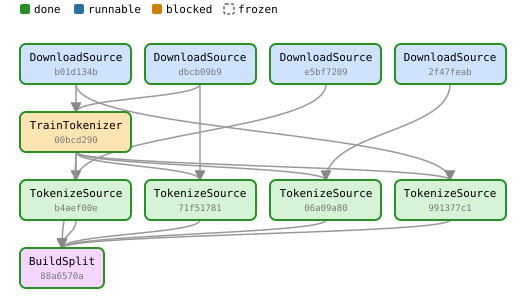

In [35]:
dag.dag_svg(dataset2)   # deep load: every box solid -- the full ancestry is real jobs again

OK: frozen=True also lands on the identical id -- trusted from the manifest, not recomputed


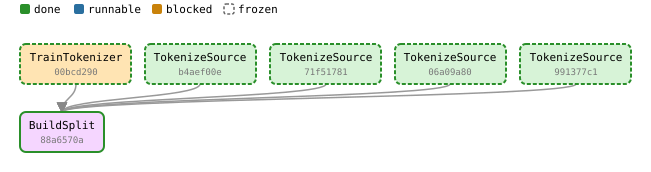

In [36]:
tokenized_frozen = {
    name: TokenizeSource.from_manifest(
        f"tokenizers/llama-64/bin/{name}/manifest.json", root=ROOT, frozen=True
    )
    for name in set(TRAIN_SET + VALID_SET)
}

dataset3 = BuildSplit(
    {"train_source_uids": TRAIN_SET, "valid_source_uids": VALID_SET,
     "tokenizer_uid": "llama-64"},
    RUN_ID, root=ROOT,
    tokenizer=[tokenizer_frozen],
    sources=[tokenized_frozen[name] for name in set(TRAIN_SET + VALID_SET)],
)
assert dataset3.id == dataset.id
print("OK: frozen=True also lands on the identical id -- trusted from the manifest, not recomputed")

dag.dag_svg(dataset3)   # tokenizer + tokenized sources render dashed -- frozen, not walked into

## 6. Verification — a manifest is never just trusted

Three ways a saved manifest can go stale, and `from_manifest` catching all
three: parameters that no longer validate, a declared output that's gone
missing, and — since deep loading is the default — an *upstream* dependency
whose parameters were quietly edited to something still-valid but different.
`verify=False` is an escape hatch for the output-existence and id-drift
checks only; parameter re-validation always runs.

In [37]:
# (a) tamper the parameters -- vocab_size becomes a string, fails the pydantic model.
# tokenizer_manifest is root-relative (what save()/from_manifest both expect),
# so touching the file directly needs ROOT joined back in.
tampered = json.loads((ROOT / tokenizer_manifest).read_text())
tampered["parameters"]["vocab_size"] = "not-an-int"
bad_params_relpath = Path(tokenizer_manifest).with_name("manifest_bad_params.json")
(ROOT / bad_params_relpath).write_text(json.dumps(tampered))

try:
    Job.from_manifest(bad_params_relpath, root=ROOT)
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK: bad parameters rejected ->", e)

OK: bad parameters rejected -> example_data/tokenizers/llama-64/manifest_bad_params.json: parameters no longer validate -- 1 validation error for Parameters
vocab_size
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='not-an-int', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/int_parsing


In [38]:
# (b) tamper the outputs -- delete one of the tokenizer's declared output files
config_path = ROOT / "tokenizers/llama-64/config.json"
config_path.unlink()

try:
    Job.from_manifest(tokenizer_manifest, root=ROOT)
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK: missing output rejected ->", e)

# verify=False bypasses the output-existence check (still re-validates parameters)
stale = Job.from_manifest(tokenizer_manifest, root=ROOT, verify=False)
print("OK: verify=False loads anyway ->", stale.frozen)

materialize(tokenizer, "config", filename="config.json", content="{}")   # restore

OK: missing output rejected -> example_data/tokenizers/llama-64/manifest.json: declared output(s) missing on disk -- ['tokenizers/llama-64/config.json']
OK: verify=False loads anyway -> False


PosixPath('example_data/tokenizers/llama-64/config.json')

In [39]:
# (c) tamper an *upstream* parameter -- edit the TrainTokenizer entry embedded
# inside the saved BuildSplit manifest's own recipe, not dataset's own
# top-level parameters at all. Still a valid int, so pydantic alone wouldn't
# catch it -- only re-deriving that level's id and comparing it does.
raw = json.loads((ROOT / dataset_manifest).read_text())
raw["dependencies"]["tokenizer"][0]["parameters"]["vocab_size"] = 999999
tampered_upstream_relpath = Path(dataset_manifest).with_name("manifest_tampered_upstream.json")
(ROOT / tampered_upstream_relpath).write_text(json.dumps(raw))

try:
    Job.from_manifest(tampered_upstream_relpath, root=ROOT)   # default: deep
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK: deep load caught the upstream tamper ->", e)

# frozen=True never looks that far upstream -- only *this* job's own params/outputs are checked
trusted_anyway = Job.from_manifest(tampered_upstream_relpath, root=ROOT, frozen=True)
print("frozen=True loads it anyway (upstream tamper is invisible to it):", trusted_anyway.frozen)

OK: deep load caught the upstream tamper -> example_data/datasets/88a6570a5cf6/manifest_tampered_upstream.json > tokenizer: id drift -- recorded '00bcd290b0ef', reconstructed '646601bb678c' (parameters or an upstream dependency no longer match what produced this manifest)
frozen=True loads it anyway (upstream tamper is invisible to it): True


## Tests

A few properties this design promises, checked directly.

In [40]:
# 1. Dependency slot names are real, explicit keyword-only parameters on
#    each job type's constructor now (not **deps) -- an unrecognized name
#    is a TypeError at the call site itself, the same as any other bad
#    keyword argument (and your editor would flag it before you even run
#    this). There's still no count to satisfy for a recognized slot: any
#    number of jobs, including zero, is accepted.
try:
    BuildSplit(
        {"train_source_uids": [], "valid_source_uids": [], "tokenizer_uid": "llama-64"},
        RUN_ID, root=ROOT, tokenizer=[tokenizer], not_a_slot=[],
    )
    raise AssertionError("expected TypeError")
except TypeError as e:
    print("OK:", e)

empty_split = BuildSplit(
    {"train_source_uids": [], "valid_source_uids": [], "tokenizer_uid": "llama-64"},
    RUN_ID, root=ROOT, tokenizer=[tokenizer], sources=[],
)
print("OK: an empty 'sources' list is accepted -- no cardinality to satisfy")

# 2. Anything that isn't a Job or a manifest path is rejected outright.
try:
    TokenizeSource(
        {"tokenizer_uid": "llama-64", "source_uid": "odyssey"},
        RUN_ID, root=ROOT, source=[{"not": "a job"}], tokenizer=[tokenizer],
    )
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK:", e)

# 3. A manifest path that doesn't exist fails loudly and immediately.
try:
    Job.from_manifest("no/such/manifest.json", root=ROOT)
    raise AssertionError("expected JobError")
except JobError as e:
    print("OK:", e)

# 4. status() is unaffected by which representation (live vs. frozen) a
#    dependency happens to be -- both resolve through the same output paths.
assert dag.status(dataset) == dag.status(dataset2) == "done"
print("OK: status agrees for live-built and manifest-built dataset")

# 5. Frozen nodes are terminal for both traversal and scheduling.
assert tokenizer_frozen.deps == {}
assert dag.scheduled(tokenizer_frozen, {}) is False
print("OK: a frozen node has no dependencies and is never scheduled")

# 6. from_manifest's default (deep) reconstructs the whole ancestry as real
#    jobs -- topo_sort sees every DownloadSource/TrainTokenizer/TokenizeSource
#    node, not one opaque leaf -- and every path (from scratch, deep, frozen)
#    still lands on the identical id.
assert len(dag.topo_sort(tokenizer_deep)) > 1
assert dataset.id == dataset2.id == dataset3.id
print("OK: deep load reconstructs real ancestry; scratch/deep/frozen ids agree")

print("\nALL TESTS PASSED")

OK: BuildSplit.__init__() got an unexpected keyword argument 'not_a_slot'
OK: an empty 'sources' list is accepted -- no cardinality to satisfy
OK: TokenizeSource: a dependency must be a Job or a manifest path, got {'not': 'a job'}
OK: manifest not found: example_data/no/such/manifest.json
OK: status agrees for live-built and manifest-built dataset
OK: a frozen node has no dependencies and is never scheduled
OK: deep load reconstructs real ancestry; scratch/deep/frozen ids agree

ALL TESTS PASSED
